<a href="https://www.kaggle.com/code/mh0386/spam-detection?scriptVersionId=138183938" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import tensorflow as tf
from kagglehub import dataset_download
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Embedding
from tensorflow.keras.layers import TextVectorization

I0000 00:00:1778446901.979899  131292 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
data = pl.read_csv(
    f'{dataset_download("team-ai/spam-text-message-classification")}/SPAM text message 20170820 - Data.csv')
data

Category,Message
str,str
"""ham""","""Go until jurong point, crazy..…"
"""ham""","""Ok lar... Joking wif u oni..."""
"""spam""","""Free entry in 2 a wkly comp to…"
"""ham""","""U dun say so early hor... U c …"
"""ham""","""Nah I don't think he goes to u…"
…,…
"""spam""","""This is the 2nd time we have t…"
"""ham""","""Will ü b going to esplanade fr…"
"""ham""","""Pity, * was in mood for that. …"


In [4]:
data.group_by('Category').len()

Category,len
str,u32
"""ham""",4825
"""spam""",747


In [5]:
ham_msg = data.filter(pl.col('Category') == 'ham')
spam_msg = data.filter(pl.col('Category') == 'spam')

In [6]:
#randomly taking data from ham_ msg
ham_msg = ham_msg.sample(n=len(spam_msg))

In [7]:
print(ham_msg.shape, spam_msg.shape)

(747, 2) (747, 2)


In [8]:
data

Category,Message
str,str
"""ham""","""Go until jurong point, crazy..…"
"""ham""","""Ok lar... Joking wif u oni..."""
"""spam""","""Free entry in 2 a wkly comp to…"
"""ham""","""U dun say so early hor... U c …"
"""ham""","""Nah I don't think he goes to u…"
…,…
"""spam""","""This is the 2nd time we have t…"
"""ham""","""Will ü b going to esplanade fr…"
"""ham""","""Pity, * was in mood for that. …"


In [9]:
balanced_data = ham_msg.vstack(spam_msg)
balanced_data = balanced_data.with_columns(
    pl.when(pl.col("Category") == 'spam').then(1).otherwise(0).alias('Category')
)

In [10]:
balanced_data

Category,Message
i32,str
0,"""Dude how do you like the buff …"
0,"""Lol they were mad at first but…"
0,"""But you were together so you s…"
0,"""Why you Dint come with us."""
0,"""Did either of you have any ide…"
…,…
1,"""Want explicit SEX in 30 secs? …"
1,"""ASKED 3MOBILE IF 0870 CHATLINE…"
1,"""Had your contract mobile 11 Mn…"


In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(
    balanced_data['Message'],
    balanced_data['Category'],
    test_size=0.2,
    random_state=42
)

In [12]:
X_train = np.array(X_train, dtype=np.chararray)
X_test = np.array(X_test, dtype=np.chararray)
X_train

/tmp/ipykernel_131292/622744040.py:1: DeprecationWarning: `np.chararray` is deprecated and will be removed from the main namespace in the future. Use an array with a string or bytes dtype instead.
  X_train = np.array(X_train, dtype=np.chararray)
/tmp/ipykernel_131292/622744040.py:2: DeprecationWarning: `np.chararray` is deprecated and will be removed from the main namespace in the future. Use an array with a string or bytes dtype instead.
  X_test = np.array(X_test, dtype=np.chararray)


array(['Thank god they are in bed!', 'K..give back my thanks.',
       'Hello darling how are you today? I would love to have a chat, why dont you tell me what you look like and what you are in to sexy?',
       ...,
       'You have an important customer service announcement from PREMIER. Call FREEPHONE 0800 542 0578 now!',
       'URGENT! Your Mobile number has been awarded with a £2000 prize GUARANTEED. Call 09061790126 from land line. Claim 3030. Valid 12hrs only 150ppm',
       'How come it takes so little time for a child who is afraid of the dark to become a teenager who wants to stay out all night?'],
      shape=(1195,), dtype=object)

In [13]:
vocab_size = 10000
sequence_length = 100

# Create the layer.
vectorized_layer = TextVectorization(
    max_tokens=vocab_size,
    output_mode='int',
    output_sequence_length=sequence_length
)

X_test = tf.expand_dims(X_test, -1)  # add a new dimension
X_test = tf.squeeze(X_test, axis=1)

X_train = tf.expand_dims(X_train, -1)  # add a new dimension
X_train = tf.squeeze(X_train, axis=1)

vectorized_layer.adapt(X_test)
vectorized_X_test = vectorized_layer(X_test)

vectorized_layer.adapt(X_train)
vectorized_X_train = vectorized_layer(X_train)

I0000 00:00:1778446936.841903  131292 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2603 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


In [14]:
Y_train = np.array(Y_train, dtype=np.int64)
Y_test = np.array(Y_test, dtype=np.int64)

# model

In [15]:
model = tf.keras.models.Sequential(
    [
        Embedding(vocab_size + 1, 100, input_length=sequence_length),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ]
)

/home/mohamed/Dev/notebooks/notebooks/deep-learning/spam-detection/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [16]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy'],
    optimizer='adam'
)

In [17]:
history = model.fit(
    vectorized_X_train,
    Y_train,
    epochs=100,
    validation_split=0.2,
    batch_size=10
)

Epoch 1/100


/home/mohamed/Dev/notebooks/notebooks/deep-learning/spam-detection/.venv/lib/python3.13/site-packages/keras/src/backend/tensorflow/nn.py:1288: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
I0000 00:00:1778446944.125242  131793 service.cc:153] XLA service 0x7d056c086410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778446944.125282  131793 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1650 Ti with Max-Q Design, Compute Capability 7.5 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778446944.219206  131793 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778446944.944099  131793 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778446944.977

27/96 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6458 - loss: 0.6503

I0000 00:00:1778446947.906567  131793 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


90/96 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7201 - loss: 0.5491

I0000 00:00:1778446949.180090  131791 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1987__.11


96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.8149 - loss: 0.4022 - val_accuracy: 0.9623 - val_loss: 0.1771
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9697 - loss: 0.0960 - val_accuracy: 0.9331 - val_loss: 0.1366
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9906 - loss: 0.0345 - val_accuracy: 0.9749 - val_loss: 0.1102
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9979 - loss: 0.0076 - val_accuracy: 0.9582 - val_loss: 0.1371
Epoch 5/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9582 - val_loss: 0.1425
Epoch 6/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 4.0586e-04 - val_accuracy: 0.9582 - val_loss: 0.1429
Epoch 7/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 2.2695e-04 - val_accuracy: 0.9582 - val_loss: 0.1471
Epoch 8/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 1.3770e-04 - val_accuracy: 0.9582 

In [18]:
model.evaluate(
    vectorized_X_test,
    Y_test
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 0.6589 - loss: 3.3561


[3.356084108352661, 0.6588628888130188]

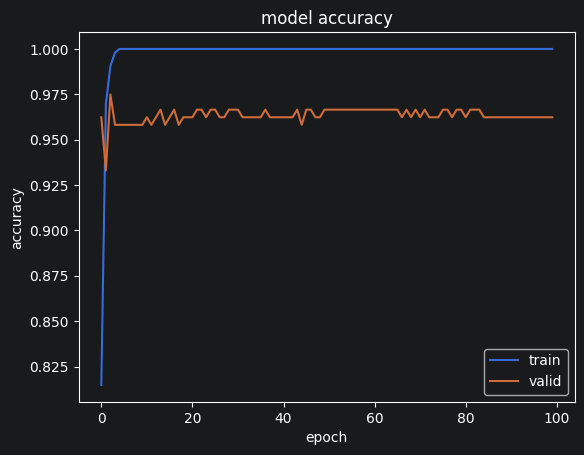

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'valid'])

In [20]:
predict_msg = [
    "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",
    "Ok lar... Joking wif u oni...",
    "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"]

In [21]:
vectorized_layer.adapt(predict_msg)
vectorized_predict_msg = vectorized_layer(predict_msg)
model.predict(vectorized_predict_msg)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 953ms/step


array([[7.7355689e-05],
       [8.5747594e-01],
       [1.0000000e+00]], dtype=float32)